In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [3]:
train = pd.read_csv("ka3_dataset/train.csv")
test = pd.read_csv("ka3_dataset/test.csv")
sample_submission = pd.read_csv("ka3_dataset/sample_submission.csv")

train["is_train"] = 1
test["is_train"] = 0

In [4]:
df = pd.concat([train, test], axis=0)
df.head()

,id,phrase,feature_1,feature_2,feature_3,sentiment,is_train
0,0,It may as well be called `` Jar-Jar Binks : Th...,14.0,5.0,7.0,0.0,1
1,1,You have to see it .,6.0,1.0,NaN,2.0,1
2,2,... either you 're willing to go with this cla...,16.0,0.0,6.0,1.0,1
3,3,Watching Harris ham it up while physically and...,37.0,NaN,3.0,1.0,1
4,4,Pete 's screenplay manages to find that real n...,20.0,1.0,4.0,2.0,1


In [5]:
df.shape, train.shape, test.shape

((8700, 7), (7000, 7), (1700, 6))

### Let's perfrom eda and fe

In [6]:
df.info()

<class 'pandas.DataFrame'>
Index: 8700 entries, 0 to 1699
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         8700 non-null   int64  
 1   phrase     8700 non-null   str    
 2   feature_1  7566 non-null   float64
 3   feature_2  7278 non-null   float64
 4   feature_3  7548 non-null   float64
 5   sentiment  7000 non-null   float64
 6   is_train   8700 non-null   int64  
dtypes: float64(4), int64(2), str(1)
memory usage: 543.8 KB


In [7]:
df.describe()

,id,feature_1,feature_2,feature_3,sentiment,is_train
count,8700.000000,7566.000000,7278.000000,7548.000000,7000.000000,8700.000000
mean,2981.683908,19.026302,1.994367,3.358771,1.041143,0.804598
std,2106.439903,9.283447,1.626308,2.367978,0.898010,0.396533
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,1087.000000,12.000000,1.000000,2.000000,0.000000,1.000000
50%,2649.500000,18.000000,1.000000,3.000000,1.000000,1.000000
75%,4824.250000,25.000000,3.000000,4.000000,2.000000,1.000000
max,6999.000000,52.000000,19.000000,23.000000,2.000000,1.000000


In [8]:
# i want to view entire phrase
pd.set_option("display.max_colwidth", None)

df["phrase"].head(5)

0                                                                                                                                                            It may as well be called `` Jar-Jar Binks : The Movie . ''
1                                                                                                                                                                                                  You have to see it .
2                                                                                                                                    ... either you 're willing to go with this claustrophobic concept or you 're not .
3    Watching Harris ham it up while physically and emotionally disintegrating over the course of the movie has a certain poignancy in light of his recent death , but Boyd 's film offers little else of consequence .
4                                                                                                     Pete 's screenplay manages to find

### Handling Phrase feature

In [9]:
df["phrase"]

0                                                                                                                                                               It may as well be called `` Jar-Jar Binks : The Movie . ''
1                                                                                                                                                                                                     You have to see it .
2                                                                                                                                       ... either you 're willing to go with this claustrophobic concept or you 're not .
3       Watching Harris ham it up while physically and emotionally disintegrating over the course of the movie has a certain poignancy in light of his recent death , but Boyd 's film offers little else of consequence .
4                                                                                                        Pete 's screenplay 

In [10]:
import re
def cleanText(text):
    text = re.sub(r"`", "", text)
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"\.{2,}", " ", text)
    text = text.replace('"', "") 
    return " ".join(text.split())

In [11]:
df["phrase"]= df["phrase"].fillna("")
df["phrase"] = df["phrase"].apply(lambda x: cleanText(x))

In [12]:
df["char_len"] = df["phrase"].str.len()
df["word_len"] = df["phrase"].str.split().str.len()

In [13]:
df["num_!"] = df["phrase"].str.count("!")
df["num_?"] = df["phrase"].str.count(r"\?")

In [14]:
df.head()
# df.groupby("sentiment")[["char_len", "word_len"]].value_counts()

,id,phrase,feature_1,feature_2,feature_3,sentiment,is_train,char_len,word_len,num_!,num_?
0,0,It may as well be called Jar-Jar Binks : The Movie . '',14.0,5.0,7.0,0.0,1,55,13,0,0
1,1,You have to see it .,6.0,1.0,NaN,2.0,1,20,6,0,0
2,2,either you 're willing to go with this claustrophobic concept or you 're not .,16.0,0.0,6.0,1.0,1,78,15,0,0
3,3,"Watching Harris ham it up while physically and emotionally disintegrating over the course of the movie has a certain poignancy in light of his recent death , but Boyd 's film offers little else of consequence .",37.0,NaN,3.0,1.0,1,210,37,0,0
4,4,"Pete 's screenplay manages to find that real natural , even-flowing tone that few movies are able to accomplish .",20.0,1.0,4.0,2.0,1,113,20,0,0


### Handling missing values

In [15]:
df.isna().sum()

id              0
phrase          0
feature_1    1134
feature_2    1422
feature_3    1152
sentiment    1700
is_train        0
char_len        0
word_len        0
num_!           0
num_?           0
dtype: int64

In [16]:
df.nunique()

id           7000
phrase       8523
feature_1      52
feature_2      16
feature_3      21
sentiment       3
is_train        2
char_len      262
word_len       52
num_!           2
num_?           3
dtype: int64

In [17]:
df.columns

Index(['id', 'phrase', 'feature_1', 'feature_2', 'feature_3', 'sentiment',
       'is_train', 'char_len', 'word_len', 'num_!', 'num_?'],
      dtype='str')

In [18]:
num_cols = ["feature_1", "feature_2", "feature_3"]
df[num_cols]

,feature_1,feature_2,feature_3
0,14.0,5.0,7.0
1,6.0,1.0,NaN
2,16.0,0.0,6.0
3,37.0,NaN,3.0
4,20.0,1.0,4.0
...,...,...,...
1695,11.0,2.0,NaN
1696,NaN,2.0,3.0
1697,25.0,1.0,1.0
1698,NaN,1.0,1.0


In [19]:
train_df = df[df["is_train"]==1]
test_df = df[df["is_train"]==0]

train_df = train_df.drop(["is_train"], axis = 1)
test_df = test_df.drop(["is_train"], axis = 1) 

train_df.shape, train.shape, test_df.shape, test.shape, 

((7000, 10), (7000, 7), (1700, 10), (1700, 6))

### Visuals

<Axes: xlabel='sentiment', ylabel='feature_1'>

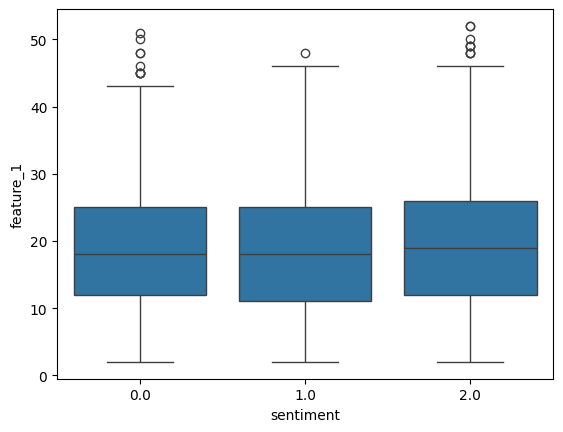

In [20]:
sns.boxplot(data = df.dropna(), x = "sentiment", y = "feature_1")

### Checking for outliers

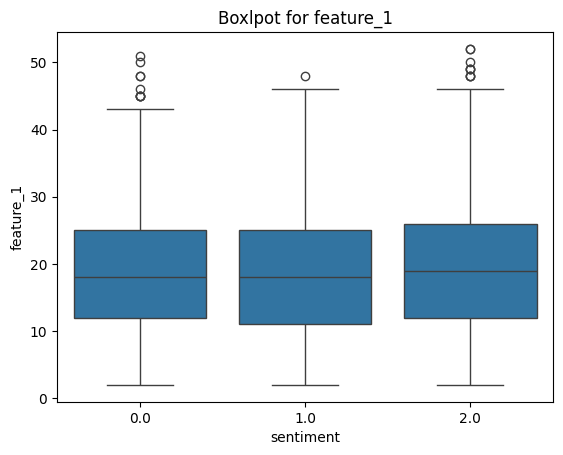

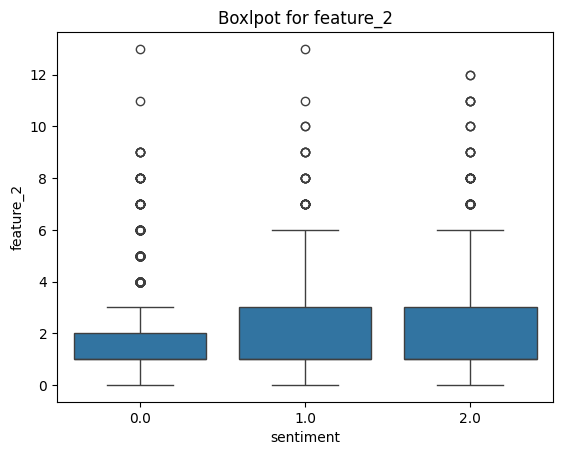

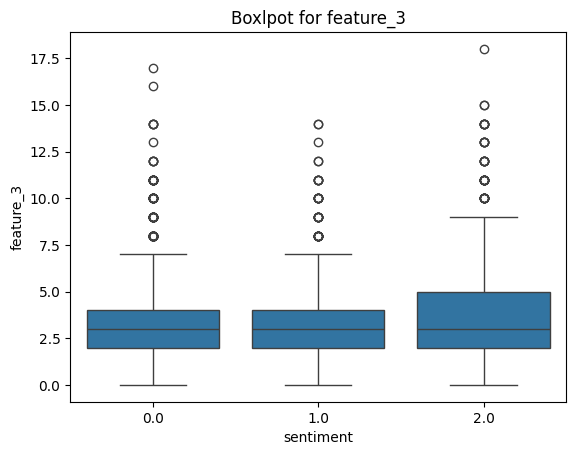

In [21]:
for i in ["feature_1", "feature_2", "feature_3"]:
    plt.title(f"Boxlpot for {i}")
    plt.xlabel = i
    sns.boxplot(data = df.dropna(), x = "sentiment", y = i)
    plt.show()

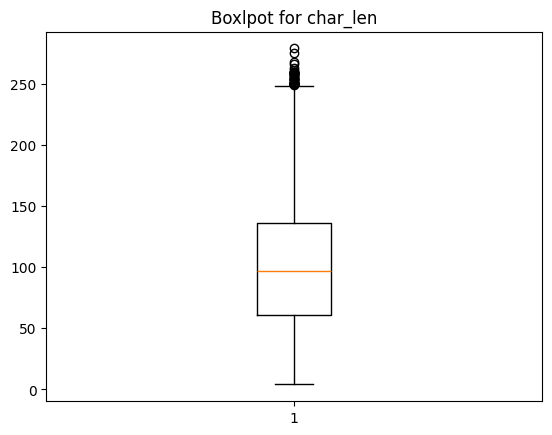

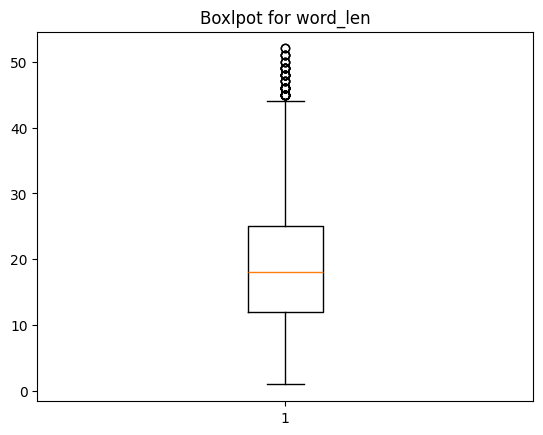

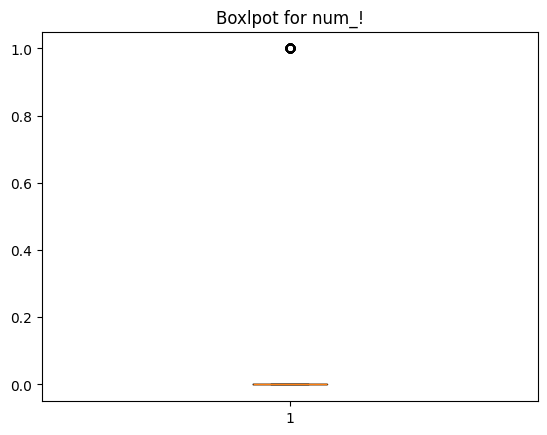

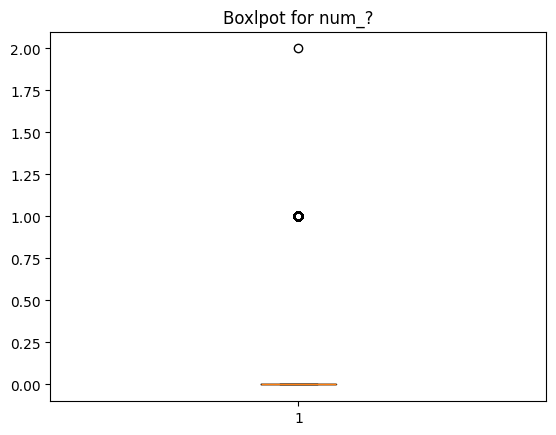

In [22]:
nums = ['char_len', 'word_len', 'num_!', 'num_?']
for i in nums:
    plt.title(f"Boxlpot for {i}")
    plt.xlabel = i
    plt.boxplot(df[i])
    plt.show()

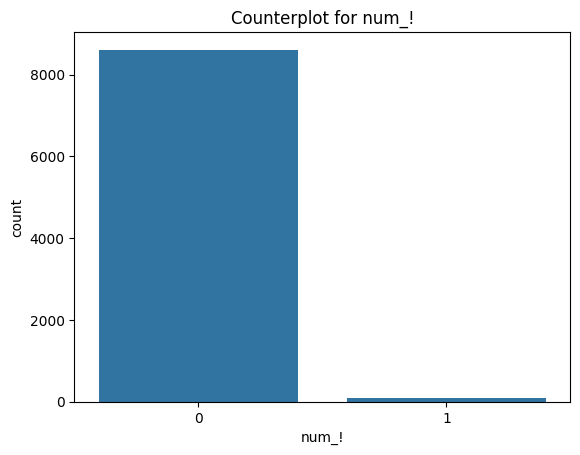

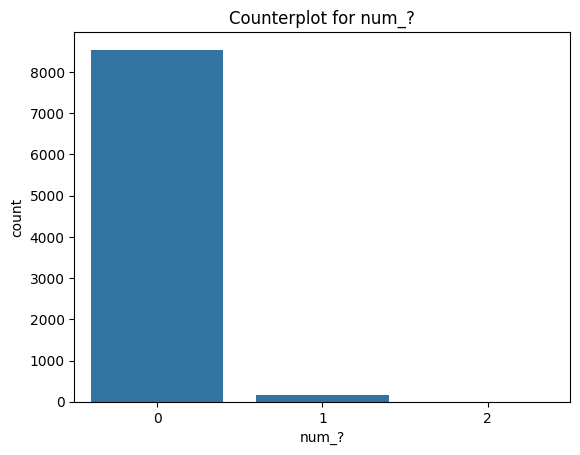

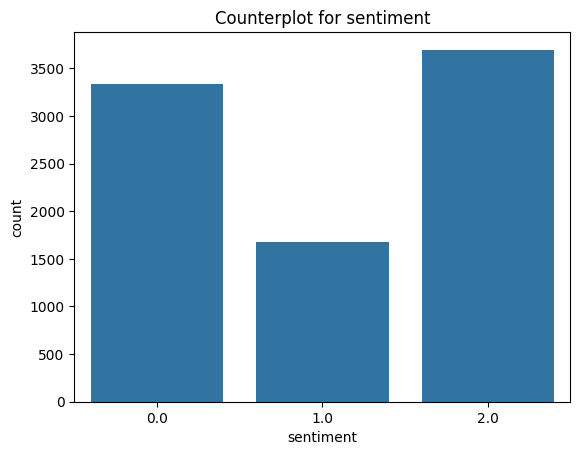

In [23]:
nums = ['num_!', 'num_?']
for i in nums+["sentiment"]:
    plt.title(f"Counterplot for {i}")
    plt.xlabel = i
    sns.countplot(data = df, x = i)
    plt.show()

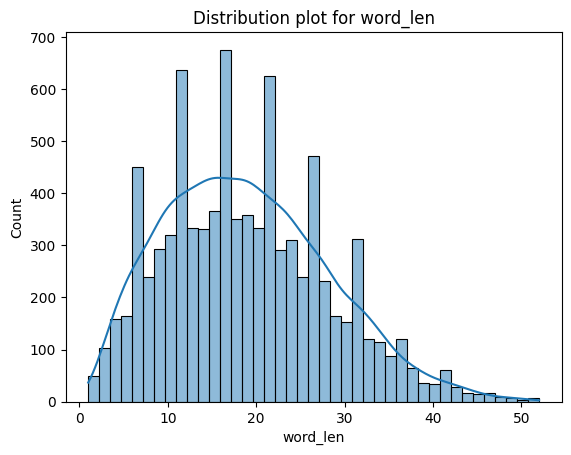

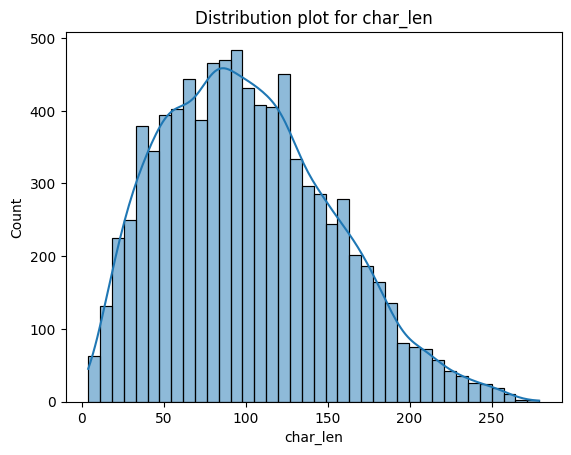

In [24]:
for i in ["word_len", "char_len"]:
    plt.title(f"Distribution plot for {i}")
    plt.xlabel = i
    sns.histplot(data = df, x = i, kde = True)
    plt.show()  

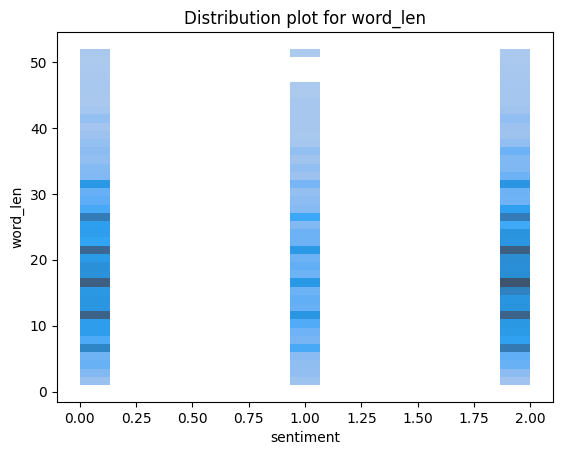

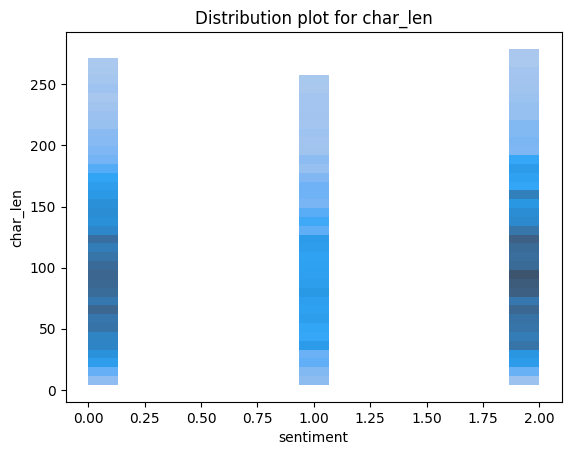

In [25]:
for i in ["word_len", "char_len"]:
    plt.title(f"Distribution plot for {i}")
    plt.xlabel = i
    sns.histplot(data = df, x = "sentiment", y = i)
    plt.show()

<Axes: >

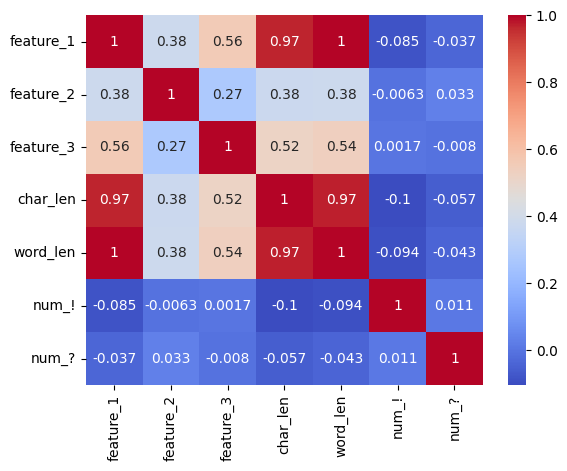

In [26]:
numcols = ["feature_1", "feature_2", "feature_3", 'char_len', 'word_len', 'num_!', 'num_?']
coef = df[numcols].corr()
sns.heatmap(coef, annot = True, cmap = "coolwarm")

In [27]:
from sklearn.model_selection import train_test_split
X = train_df.drop(["sentiment", "word_len"], axis = 1)
y = train_df["sentiment"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify= y
)

### Feature selection and feature importance

In [28]:
from sklearn.feature_selection import SelectKBest, chi2, f_classif, mutual_info_classif

for i in [chi2, f_classif, mutual_info_classif]:
    print(i.__name__)
    skb = SelectKBest(k = 5, score_func=i)
    skb.fit(df.dropna()[numcols], df.dropna()["sentiment"])
    print(skb.get_feature_names_out())

chi2
['feature_1' 'feature_2' 'char_len' 'word_len' 'num_?']
f_classif
['feature_1' 'feature_2' 'char_len' 'word_len' 'num_?']
mutual_info_classif
['feature_1' 'feature_3' 'char_len' 'word_len' 'num_?']


### Using embeddings + numerical features

In [36]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer("all-mpnet-base-v2", device="cuda")
train_emb = model.encode(X_train["phrase"].tolist(), show_progress_bar=True, batch_size=32)
val_emb = model.encode(X_val["phrase"].tolist(), show_progress_bar=True, batch_size=32)
test_emb = model.encode(test_df["phrase"].tolist(), show_progress_bar=True, batch_size=32)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/175 [00:00<?, ?it/s]

Batches:   0%|          | 0/44 [00:00<?, ?it/s]

Batches:   0%|          | 0/54 [00:00<?, ?it/s]

In [37]:
train_emb.shape, val_emb.shape, test_emb.shape

((5600, 768), (1400, 768), (1700, 768))

In [38]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline, FeatureUnion #used for two or more text vectorizer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer

num_cols = ["feature_1", "feature_2", "feature_3", "char_len","num_!", "num_?"]

numerical_cols = Pipeline([
    ("impute",SimpleImputer(strategy='median', add_indicator=True)),
    ("scale", StandardScaler(with_mean=False)) # with_mean=False because of sparse matrix from tfidf vectorizer
])

tfidf_pipe = FeatureUnion([
    ("word",TfidfVectorizer(ngram_range=(1,2), min_df=1, max_features=30000)),
    ("char", TfidfVectorizer(ngram_range=(3,4), min_df=1, max_features=30000, analyzer="char"))
])

process = ColumnTransformer(transformers=[
    ("nums", numerical_cols, num_cols),
    ("text", tfidf_pipe, "phrase")
])

X_train_num = process.fit_transform(X_train)
X_val_num = process.transform(X_val)
test_num = process.transform(test_df)

In [39]:
X_train_num.shape, X_val_num.shape, test_num.shape

((5600, 60009), (1400, 60009), (1700, 60009))

In [55]:
#merge
from scipy.sparse import hstack 
X_train_final = hstack([train_emb, X_train_num]) #testing with just mpnet
X_val_final = hstack([val_emb, X_val_num])
test_final = hstack([test_emb, test_num])

# what do i di it's giving 2D error ? let's try without hstack - Concluded it perfrom poor than mpnet + nums_col
# X_train_final = train_emb
# X_val_final = val_emb
# test_final = test_emb

In [56]:
X_train_final.shape, X_val_final.shape, test_final.shape

((5600, 60777), (1400, 60777), (1700, 60777))

In [57]:
# from sklearn.impute import SimpleImputer
# from sklearn.pipeline import Pipeline, FeatureUnion #used for two or more text vectorizer
# from sklearn.compose import ColumnTransformer
# from sklearn.preprocessing import StandardScaler
# from sklearn.feature_extraction.text import TfidfVectorizer

# num_cols = ["feature_1", "feature_2", "feature_3", "char_len","num_!", "num_?"]

# numerical_cols = Pipeline([
#     ("impute",SimpleImputer(strategy='median', add_indicator=True)),
#     ("scale", StandardScaler(with_mean=False)) # with_mean=False because of sparse matrix from tfidf vectorizer
# ])

# tfidf_pipe = FeatureUnion([
#     ("word",TfidfVectorizer(ngram_range=(1,2), min_df=1, max_features=30000)),
#     ("char", TfidfVectorizer(ngram_range=(3,4), min_df=1, max_features=30000, analyzer="char"))
# ])

# process = ColumnTransformer(transformers=[
#     ("nums", numerical_cols, num_cols),
#     ("text", tfidf_pipe, "phrase")
# ])



In [58]:
# X_train_final = process.fit_transform(X_train)
# X_val_final = process.transform(X_val)
# test_final = process.transform(test_df)

In [59]:
X_train_final.shape, X_val_final.shape, test_final.shape 

((5600, 60777), (1400, 60777), (1700, 60777))

### Model training and evaluation

In [60]:
from sklearn.linear_model import RidgeClassifier, SGDClassifier, LogisticRegression
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC

In [61]:
model = {
    "LogisticReg": LogisticRegression(max_iter=1000),
    "RidgeClassifier": RidgeClassifier(),
    "SGDClassifier": SGDClassifier(loss= "log_loss"),
    "LinearSVC": LinearSVC(max_iter=3000),
    "DecisionTreeClassifier": DecisionTreeClassifier(),
    # "AdaBoostClassifier": AdaBoostClassifier()
    # "GradientBoostingClassifier": GradientBoostingClassifier(),
    # "RandomForestClassifier": RandomForestClassifier()
}

In [62]:
from sklearn.metrics import classification_report, accuracy_score

for name, model in model.items():
    model.fit(X_train_final, y_train)
    y_preds = model.predict(X_val_final)
    print(f"{name} accurace is : {accuracy_score(y_val, y_preds):.4f} \n {classification_report(y_val, y_preds)}")
    print()


LogisticReg accurace is : 0.7286 
               precision    recall  f1-score   support

         0.0       0.74      0.81      0.78       537
         1.0       0.46      0.23      0.30       269
         2.0       0.77      0.88      0.82       594

    accuracy                           0.73      1400
   macro avg       0.66      0.64      0.63      1400
weighted avg       0.70      0.73      0.70      1400


RidgeClassifier accurace is : 0.7200 
               precision    recall  f1-score   support

         0.0       0.74      0.80      0.77       537
         1.0       0.42      0.22      0.29       269
         2.0       0.77      0.87      0.82       594

    accuracy                           0.72      1400
   macro avg       0.64      0.63      0.62      1400
weighted avg       0.69      0.72      0.70      1400


SGDClassifier accurace is : 0.7300 
               precision    recall  f1-score   support

         0.0       0.70      0.85      0.77       537
         1.0    

### HPT

In [48]:
# hyperparameter tuning - lr
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr = LogisticRegression(max_iter=1000)
param_grid = {
    "C": [0.3, 0.5, 0.75, 1, 1.5, 2, 3],
    "class_weight": [None],
    "solver": ["lbfgs", "saga"]
}
random_lr = RandomizedSearchCV(estimator=lr, param_distributions=param_grid, cv=cv, n_jobs=-1, verbose=2, scoring="accuracy")
random_lr.fit(X_train_final, y_train)
print(f"Best parameters: {random_lr.best_params_}")
best_lr = random_lr.best_estimator_
y_preds = best_lr.predict(X_val_final)
print(f"LogisticReg accurace is : {accuracy_score(y_val, y_preds):.4f} \n {classification_report(y_val, y_preds)}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END ..............C=0.5, class_weight=None, solver=saga; total time=  33.0s
[CV] END ............C=0.75, class_weight=None, solver=lbfgs; total time=  38.9s
[CV] END ...............C=3, class_weight=None, solver=lbfgs; total time=  40.2s
[CV] END ............C=0.75, class_weight=None, solver=lbfgs; total time=  41.4s
[CV] END ...............C=3, class_weight=None, solver=lbfgs; total time=  45.8s
[CV] END ...............C=3, class_weight=None, solver=lbfgs; total time=  49.0s
[CV] END ...............C=3, class_weight=None, solver=lbfgs; total time=  52.0s
[CV] END ...............C=3, class_weight=None, solver=lbfgs; total time=  56.1s
[CV] END ..............C=0.5, class_weight=None, solver=saga; total time=  57.8s
[CV] END ..............C=0.5, class_weight=None, solver=saga; total time= 1.0min
[CV] END ..............C=0.5, class_weight=None, solver=saga; total time= 1.0min
[CV] END ..............C=0.5, class_weight=None,

/home/kradarsh/Desktop/ML_core/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END ................C=2, class_weight=None, solver=saga; total time= 2.7min
[CV] END .............C=0.75, class_weight=None, solver=saga; total time=  38.7s
[CV] END .............C=0.75, class_weight=None, solver=saga; total time=  53.7s
[CV] END .............C=0.75, class_weight=None, solver=saga; total time=  39.9s
Best parameters: {'solver': 'saga', 'class_weight': None, 'C': 0.5}
LogisticReg accurace is : 0.7314 
               precision    recall  f1-score   support

         0.0       0.73      0.83      0.78       537
         1.0       0.49      0.19      0.27       269
         2.0       0.77      0.89      0.82       594

    accuracy                           0.73      1400
   macro avg       0.66      0.64      0.62      1400
weighted avg       0.70      0.73      0.70      1400



```markdown
Best parameters: {'solver': 'liblinear', 'class_weight': None, 'C': 1}
LogisticReg accurace is : 0.6550 
               precision    recall  f1-score   support

         0.0       0.66      0.72      0.69       537
         1.0       0.42      0.08      0.14       269
         2.0       0.67      0.86      0.75       594

    accuracy                           0.66      1400
   macro avg       0.58      0.55      0.53      1400
weighted avg       0.62      0.66      0.61      1400
-------
Best parameters: {'solver': 'lbfgs', 'class_weight': None, 'C': 1}
LogisticReg accurace is : 0.6550 
               precision    recall  f1-score   support

         0.0       0.66      0.72      0.69       537
         1.0       0.40      0.13      0.19       269
         2.0       0.68      0.84      0.75       594

    accuracy                           0.66      1400
   macro avg       0.58      0.56      0.54      1400
weighted avg       0.62      0.66      0.62      1400
```

In [67]:
# we learnt that balanced weights were not best for accuracy.. - valid for all models(verified)

lsvc = LinearSVC()
param_grid = {
    "C": [0.1, 0.3, 1, 3, 10],
    "class_weight": [None],
    "max_iter": [8000, 3000, 5000]
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
random_ = RandomizedSearchCV(estimator=lsvc, param_distributions=param_grid, cv =cv, n_jobs=-1, verbose=2, scoring="accuracy")
random_.fit(X_train_final, y_train)
print(f"Best parameters: {random_.best_params_}")
best_lsvc = random_.best_estimator_
y_preds = best_lsvc.predict(X_val_final)
print(f"LinearSVC accurace is : {accuracy_score(y_val, y_preds):.4f} \n {classification_report(y_val, y_preds)}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END ............C=0.1, class_weight=None, max_iter=8000; total time=  44.6s
[CV] END ............C=0.3, class_weight=None, max_iter=3000; total time=  50.4s
[CV] END ............C=0.1, class_weight=None, max_iter=8000; total time=  49.9s
[CV] END ............C=0.1, class_weight=None, max_iter=8000; total time=  22.2s
[CV] END ............C=0.3, class_weight=None, max_iter=3000; total time= 1.3min
[CV] END ............C=0.3, class_weight=None, max_iter=3000; total time= 1.5min
[CV] END ............C=0.3, class_weight=None, max_iter=3000; total time= 1.5min
[CV] END ............C=0.1, class_weight=None, max_iter=8000; total time=  42.4s
[CV] END ............C=0.3, class_weight=None, max_iter=3000; total time= 1.6min
[CV] END ............C=0.1, class_weight=None, max_iter=8000; total time=  48.2s
[CV] END ..............C=1, class_weight=None, max_iter=5000; total time= 1.5min


/home/kradarsh/Desktop/ML_core/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV] END .............C=10, class_weight=None, max_iter=3000; total time= 3.6min


/home/kradarsh/Desktop/ML_core/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV] END .............C=10, class_weight=None, max_iter=3000; total time= 3.6min


...

[CV] END .............C=10, class_weight=None, max_iter=3000; total time= 3.7min
[CV] END ..............C=1, class_weight=None, max_iter=5000; total time= 2.2min


/home/kradarsh/Desktop/ML_core/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV] END .............C=10, class_weight=None, max_iter=3000; total time= 3.8min
[CV] END ..............C=1, class_weight=None, max_iter=3000; total time= 2.6min
[CV] END ..............C=1, class_weight=None, max_iter=5000; total time= 2.6min
[CV] END ..............C=1, class_weight=None, max_iter=5000; total time= 3.0min
[CV] END ............C=0.1, class_weight=None, max_iter=3000; total time=  23.7s
[CV] END ............C=0.1, class_weight=None, max_iter=3000; total time=  50.4s
[CV] END ..............C=1, class_weight=None, max_iter=3000; total time= 1.9min
[CV] END ............C=0.1, class_weight=None, max_iter=3000; total time=  52.7s
[CV] END ............C=0.1, class_weight=None, max_iter=3000; total time=  47.2s
[CV] END ..............C=1, class_weight=None, max_iter=8000; total time= 1.6min
[CV] END ............C=0.1, class_weight=None, max_iter=3000; total time=  54.2s
[CV] END ..............C=1, class_weight=None, max_iter=3000; total time= 2.0min
[CV] END ..............C=1, 

/home/kradarsh/Desktop/ML_core/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV] END .............C=10, class_weight=None, max_iter=8000; total time= 4.6min
Best parameters: {'max_iter': 8000, 'class_weight': None, 'C': 0.1}
LinearSVC accurace is : 0.7336 
               precision    recall  f1-score   support

         0.0       0.73      0.84      0.78       537
         1.0       0.52      0.15      0.24       269
         2.0       0.76      0.90      0.83       594

    accuracy                           0.73      1400
   macro avg       0.67      0.63      0.61      1400
weighted avg       0.70      0.73      0.69      1400



```markdown
Best parameters: {'max_iter': 1000, 'class_weight': None, 'C': 0.3}
LinearSVC accurace is : 0.6514 
               precision    recall  f1-score   support

         0.0       0.66      0.70      0.68       537
         1.0       0.37      0.15      0.22       269
         2.0       0.69      0.84      0.76       594

    accuracy                           0.65      1400
   macro avg       0.57      0.56      0.55      1400
weighted avg       0.62      0.65      0.62      1400
```

In [64]:
sgd = SGDClassifier()
param_grid = {
    "loss": ["hinge", "log_loss", "modified_huber"],
    "alpha": [1e-5, 3e-5, 1e-4, 3e-4, 1e-3],
    "penalty": ["l2", "elasticnet"],

    "max_iter": [1000, 3000, 5000]
}           
random_sgd = RandomizedSearchCV(estimator=sgd, param_distributions=param_grid, cv=cv, n_jobs=-1, verbose=2, scoring="accuracy")
random_sgd.fit(X_train_final, y_train)
print(f"Best parameters: {random_sgd.best_params_}")
best_sgd = random_sgd.best_estimator_
y_preds = best_sgd.predict(X_val_final)
print(f"SGDClassifier accurace is : {accuracy_score(y_val, y_preds):.4f} \n {classification_report(y_val, y_preds)}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END alpha=0.0003, loss=modified_huber, max_iter=3000, penalty=elasticnet; total time=   3.7s
[CV] END alpha=0.0001, loss=modified_huber, max_iter=5000, penalty=elasticnet; total time=   5.5s
[CV] END alpha=0.0003, loss=modified_huber, max_iter=3000, penalty=elasticnet; total time=   4.6s
[CV] END alpha=0.0001, loss=modified_huber, max_iter=3000, penalty=elasticnet; total time=   6.5s
[CV] END alpha=0.0001, loss=modified_huber, max_iter=3000, penalty=elasticnet; total time=   7.4s
[CV] END alpha=0.0001, loss=modified_huber, max_iter=5000, penalty=elasticnet; total time=   7.1s
[CV] END alpha=0.0001, loss=modified_huber, max_iter=3000, penalty=elasticnet; total time=   7.7s
[CV] END alpha=0.0001, loss=modified_huber, max_iter=5000, penalty=elasticnet; total time=   7.6s
[CV] END alpha=0.0001, loss=modified_huber, max_iter=5000, penalty=elasticnet; total time=   7.0s
[CV] END alpha=0.0001, loss=modified_huber, max_iter=3000

```markdown
Best parameters: {'max_iter': 3000, 'loss': 'hinge', 'class_weight': None, 'alpha': 0.0001}
SGDClassifier accurace is : 0.6229 
               precision    recall  f1-score   support

         0.0       0.67      0.62      0.65       537
         1.0       0.32      0.22      0.26       269
         2.0       0.67      0.80      0.73       594

    accuracy                           0.62      1400
   macro avg       0.55      0.55      0.55      1400
weighted avg       0.60      0.62      0.61      1400
```

## Comparision of models

LogisticRegression accurace is : 0.7314 
               precision    recall  f1-score   support

         0.0       0.73      0.83      0.78       537
         1.0       0.49      0.19      0.27       269
         2.0       0.77      0.89      0.82       594

    accuracy                           0.73      1400
   macro avg       0.66      0.64      0.62      1400
weighted avg       0.70      0.73      0.70      1400


LinearSVC accurace is : 0.7336 
               precision    recall  f1-score   support

         0.0       0.73      0.84      0.78       537
         1.0       0.52      0.15      0.24       269
         2.0       0.76      0.90      0.83       594

    accuracy                           0.73      1400
   macro avg       0.67      0.63      0.61      1400
weighted avg       0.70      0.73      0.69      1400


SGDClassifier accurace is : 0.7221 
               precision    recall  f1-score   support

         0.0       0.70      0.87      0.78       537
         1.0   

<Axes: >

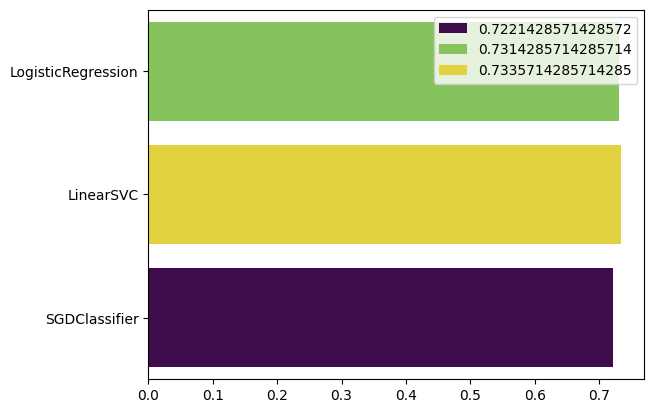

In [65]:
# all hpt comparisions results
models = {
    "LogisticRegression": best_lr,
    "LinearSVC": best_lsvc,
    "SGDClassifier": best_sgd,
}
res = {}
for name, model in models.items():
    y_preds = model.predict(X_val_final)
    res[name] = accuracy_score(y_val, y_preds)
    print(f"{name} accurace is : {accuracy_score(y_val, y_preds):.4f} \n {classification_report(y_val, y_preds)}")
    print()

# plot
sns.barplot(y = list(res.keys()), x = list(res.values()),hue = list(res.values()), palette = "viridis")

## Ensembling

In [66]:
from sklearn.ensemble import VotingClassifier
ensemble = VotingClassifier(
    estimators=[
        ("lr", best_lr),
        ("svc", best_lsvc)
    ],
    voting="hard"
)
ensemble.fit(X_train_final, y_train)
y_preds = ensemble.predict(X_val_final)
print(f"Ensemble accurace is : {accuracy_score(y_val, y_preds):.4f} \n {classification_report(y_val, y_preds)}")

Ensemble accurace is : 0.7336 
               precision    recall  f1-score   support

         0.0       0.72      0.85      0.78       537
         1.0       0.51      0.16      0.24       269
         2.0       0.77      0.89      0.82       594

    accuracy                           0.73      1400
   macro avg       0.67      0.63      0.62      1400
weighted avg       0.70      0.73      0.70      1400



## Submission 

In [ ]:
y_preds_test = ensemble.predict(test_final)
submission = sample_submission.copy(deep=True)
submission["sentiment"] = y_preds_test
submission.to_csv("submission.csv", index=False)

,id,sentiment
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0
...,...,...
1695,1695,0
1696,1696,0
1697,1697,0
1698,1698,0
